# 02 · Training — ResNet-18 (Baseline)

Fine-tune a ResNet-18 backbone (stem + layer1 + layer2 frozen; layer3, layer4, and classification head trainable). AdamW lr=3e-4, CosineAnnealingLR, 30 epochs. Checkpoint selected by best val PR-AUC.

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms, datasets
from torchvision import models
from tqdm.auto import tqdm
from PIL import Image
import numpy as np
import pandas as pd
import random
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, average_precision_score, roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix, auc
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

/alloc/data/.cache/virtualenvs/app-C8FdE8xm-py3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
IMG_SIZE = 224
BATCH_SIZE = 512
NUM_WORKERS = 4
EPOCHS = 30
LR = 3e-4
WEIGHT_DECAY = 1e-4
THRESHOLD = 0.5           
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

cuda


In [3]:
class FaceDataset(Dataset):
    def __init__(self, df, root_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.paths = self.df['path'].to_numpy()
        self.labels = self.df['label'].to_numpy()
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        full_path = f"{self.root_dir}/{self.paths[idx]}"
        img = cv2.imread(full_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(image=img)['image']
        return img, torch.tensor(self.labels[idx], dtype=torch.float32)

    def __repr__(self):
        n_pos = int((self.labels == 1).sum())
        n_neg = int((self.labels == 0).sum())
        return f"FaceDataset(n={len(self)}, pos={n_pos}, neg={n_neg})"

In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMG_SIZE = 224

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE, interpolation=cv2.INTER_LINEAR),

    A.HorizontalFlip(p=0.5),

    A.Affine(
        scale=(0.97, 1.03),
        translate_percent=(-0.02, 0.02),
        rotate=(-5, 5),
        shear=(-2, 2),
        interpolation=cv2.INTER_LINEAR,
        border_mode=cv2.BORDER_CONSTANT,
        fill=0,
        p=0.4,
    ),
    
    A.ImageCompression(quality_range=(50, 95), p=0.7),
    
    A.OneOf([
        A.Downscale(scale_range=(0.7, 0.9), interpolation_pair={
            "downscale": cv2.INTER_AREA, "upscale": cv2.INTER_LINEAR
        }, p=1.0),
        A.GaussianBlur(blur_limit=(3, 5), sigma_limit=(0.3, 1.2), p=1.0),
        A.MotionBlur(blur_limit=(3, 5), p=1.0),
    ], p=0.35),
    
    A.OneOf([
        A.GaussNoise(std_range=(0.02, 0.07), p=1.0),
        A.ISONoise(color_shift=(0.01, 0.03), intensity=(0.1, 0.3), p=1.0),
        A.MultiplicativeNoise(multiplier=(0.95, 1.05), p=1.0),
    ], p=0.25),
    
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),

    A.OneOf([
        A.HueSaturationValue(hue_shift_limit=6, sat_shift_limit=15, val_shift_limit=10, p=1.0),
        A.RGBShift(r_shift_limit=10, g_shift_limit=10, b_shift_limit=10, p=1.0),
        A.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.02, p=1.0),
    ], p=0.35),
    
    A.CoarseDropout(
        num_holes_range=(1, 2),
        hole_height_range=(0.03, 0.08),
        hole_width_range=(0.03, 0.08),
        fill=0,
        p=0.2,
    ),

    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

eval_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE, interpolation=cv2.INTER_LINEAR),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

In [5]:
train = pd.read_parquet('./07 Splits/train.parquet')
test = pd.read_parquet('./07 Splits/test.parquet')
val = pd.read_parquet('./07 Splits/val.parquet')

In [6]:
ROOT_DIRS = '03 All Data'
train_dataset = FaceDataset(train, ROOT_DIRS, transform = train_transform)
val_dataset = FaceDataset(test, ROOT_DIRS, transform = eval_transform)
test_dataset = FaceDataset(val, ROOT_DIRS, transform = eval_transform)

print(f"Train : {train_dataset}")
print(f"Val : {val_dataset}")
print(f"Test : {test_dataset}")

train_loader = DataLoader(
    train_dataset, batch_size = BATCH_SIZE, shuffle=True,
    num_workers = NUM_WORKERS, pin_memory=True, drop_last=True,
)
val_loader = DataLoader(
    val_dataset, batch_size = BATCH_SIZE, shuffle=False,
    num_workers = NUM_WORKERS, pin_memory=True,
)
test_loader = DataLoader(
    test_dataset, batch_size = BATCH_SIZE, shuffle=False,
    num_workers = NUM_WORKERS, pin_memory=True,
)

print(f"\nBatches/epoch: {len(train_loader)} train | {len(val_loader)} val | {len(test_loader)} test")

Train : FaceDataset(n=78394, pos=39197, neg=39197)
Val : FaceDataset(n=10000, pos=100, neg=9900)
Test : FaceDataset(n=11600, pos=116, neg=11484)

Batches/epoch: 153 train | 20 val | 23 test


In [7]:
class DeepfakeClassifier(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        resnet = models.resnet18(
            weights=models.ResNet18_Weights.DEFAULT if pretrained else None
        )

        for p in resnet.parameters():
            p.requires_grad = False
        # for p in resnet.layer2.parameters():
        #     p.requires_grad = True
        for p in resnet.layer3.parameters():
            p.requires_grad = True
        for p in resnet.layer4.parameters():
            p.requires_grad = True

        self.conv1 = resnet.conv1
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4
        self.avgpool = resnet.avgpool

        self.head = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2),
            nn.Linear(256, 1),
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        return self.head(x).squeeze(1)

In [8]:
def compute_metrics(labels: np.ndarray, scores: np.ndarray, threshold: float = 0.5) -> dict:
    labels = np.asarray(labels).astype(int)
    scores = np.asarray(scores)
    preds = (scores >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        "accuracy":    accuracy_score(labels, preds),
        "precision":   precision_score(labels, preds, zero_division=0),
        "recall":      recall_score(labels, preds, zero_division=0),
        "specificity": specificity,
        "f1":          f1_score(labels, preds, zero_division=0),
        "pr_auc":      average_precision_score(labels, scores),
        "roc_auc":     roc_auc_score(labels, scores),
        "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn),
        "threshold":   threshold,
    }


def find_best_threshold(labels: np.ndarray, scores: np.ndarray) -> float:
    p, r, t = precision_recall_curve(labels, scores)
    f1 = 2 * p * r / (p + r + 1e-9)
    return float(t[np.argmax(f1[:-1])])

def plot_pr_roc_curves(labels: np.ndarray, scores: np.ndarray, title_suffix: str = "", save_path: str = None):
    labels = np.asarray(labels).astype(int)
    scores = np.asarray(scores)

    prec, rec, _ = precision_recall_curve(labels, scores)
    fpr, tpr, _ = roc_curve(labels, scores)
    pr_auc = average_precision_score(labels, scores)
    roc_auc = roc_auc_score(labels, scores)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Precision-Recall
    ax1.plot(rec, prec, color='#1f77b4', lw=2, label=f'PR-AUC = {pr_auc:.3f}')
    baseline = labels.mean()
    ax1.axhline(baseline, ls='--', color='gray', lw=1,
                label=f'Baseline (prevalencia) = {baseline:.3f}')
    ax1.set_xlabel('Recall')
    ax1.set_ylabel('Precision')
    ax1.set_title(f'Curva Precision-Recall {title_suffix}')
    ax1.set_xlim([0, 1]); ax1.set_ylim([0, 1.02])
    ax1.legend(loc='lower left')
    ax1.grid(alpha=0.3)

    # ROC
    ax2.plot(fpr, tpr, color='#d62728', lw=2, label=f'ROC-AUC = {roc_auc:.3f}')
    ax2.plot([0, 1], [0, 1], ls='--', color='gray', lw=1, label='Azar')
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate (Recall)')
    ax2.set_title(f'Curva ROC {title_suffix}')
    ax2.set_xlim([0, 1]); ax2.set_ylim([0, 1.02])
    ax2.legend(loc='lower right')
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()
    return fig

In [9]:
def train_epoch(model, loader, criterion, optimizer, device, epoch):
    model.train()

    total_loss = 0.0
    n_seen = 0
    all_labels = []
    all_scores = []

    pbar = tqdm(loader, desc=f"[Train] Epoch {epoch:02d}", leave=True, dynamic_ncols=True)

    for x, y in pbar:
        x = x.to(device, non_blocking=True)
        y_bin = y.float().to(device)

        logits = model(x)
        loss = criterion(logits, y_bin)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        batch_size = x.size(0)
        total_loss += loss.item() * batch_size
        n_seen += batch_size

        scores = torch.sigmoid(logits).detach().cpu().numpy()
        all_scores.extend(scores.tolist())
        all_labels.extend(y_bin.cpu().numpy().tolist())

        pbar.set_postfix({"loss": f"{total_loss / n_seen:.4f}"})

    avg_loss = total_loss / n_seen
    metrics = compute_metrics(np.array(all_labels), np.array(all_scores))

    tqdm.write(
        f"[Train] Epoch {epoch:02d} | loss={avg_loss:.4f} "
        f"acc={metrics['accuracy']:.3f} f1={metrics['f1']:.3f} "
        f"pr_auc={metrics['pr_auc']:.3f} roc_auc={metrics['roc_auc']:.3f}"
    )
    return avg_loss, metrics


@torch.no_grad()
def val_epoch(model, loader, criterion, device, epoch):
    model.eval()

    total_loss = 0.0
    n_seen = 0
    all_labels = []
    all_scores = []

    pbar = tqdm(loader, desc=f"[Val]   Epoch {epoch:02d}", leave=True, dynamic_ncols=True)

    for x, y in pbar:
        x = x.to(device, non_blocking=True)
        y_bin = y.float().to(device)

        logits = model(x)
        loss = criterion(logits, y_bin)

        batch_size = x.size(0)
        total_loss += loss.item() * batch_size
        n_seen += batch_size

        scores = torch.sigmoid(logits).cpu().numpy()
        all_scores.extend(scores.tolist())
        all_labels.extend(y_bin.cpu().numpy().tolist())

        pbar.set_postfix({"loss": f"{total_loss / n_seen:.4f}"})

    avg_loss = total_loss / n_seen
    metrics = compute_metrics(np.array(all_labels), np.array(all_scores))

    return avg_loss, metrics

In [10]:
model = DeepfakeClassifier(pretrained=True).to(DEVICE)
criterion = nn.BCEWithLogitsLoss()

trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable_params, lr=LR, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/melibuntu/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 139MB/s]


In [11]:
total = sum(p.numel() for p in model.parameters())
trainable_n = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parámetros totales     : {total:,}")

Parámetros totales     : 11,308,097


In [12]:
def plot_metrics(history):
    epochs = [h["epoch"] for h in history]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))


    axes[0].plot(epochs, [h["train_loss"] for h in history], label="train", lw=2)
    axes[0].plot(epochs, [h["val_loss"] for h in history], label="val", lw=2)
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)


    axes[1].plot(epochs, [h["train_pr_auc"] for h in history], label="train", lw=2)
    axes[1].plot(epochs, [h["val_pr_auc"] for h in history], label="val", lw=2)
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("PR-AUC")
    axes[1].set_title("PR-AUC"); axes[1].legend(); axes[1].grid(alpha=0.3)


    axes[2].plot(epochs, [h["val_precision"] for h in history], label="precision", lw=2)
    axes[2].plot(epochs, [h["val_recall"] for h in history], label="recall", lw=2)
    axes[2].plot(epochs, [h["val_f1"] for h in history], label="f1", lw=2)
    axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Score")
    axes[2].set_title("Val: precision / recall / f1 @ thr=0.5")
    axes[2].legend(); axes[2].grid(alpha=0.3); axes[2].set_ylim([0, 1.02])

    plt.tight_layout()
    plt.savefig('./06 Figures/training_curves_r18.png', dpi=120, bbox_inches='tight')
    plt.close(fig)

In [13]:
best_pr_auc = 0.0
history = []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}  (lr={optimizer.param_groups[0]['lr']:.8f})")

    train_loss, train_m = train_epoch(model, train_loader, criterion, optimizer, DEVICE, epoch+1)
    val_loss, val_m = val_epoch(model, val_loader, criterion, DEVICE, epoch+1)
    scheduler.step()

    history.append({
        "epoch": epoch+1,
        "train_loss": train_loss, "val_loss": val_loss,
        "train_pr_auc": train_m["pr_auc"], "val_pr_auc": val_m["pr_auc"],
        "val_f1": val_m["f1"], "val_recall": val_m["recall"],
        "val_precision": val_m["precision"],
    })

    print(f"""
Train  
    loss={train_loss:.4f}  | pr_auc={train_m['pr_auc']:.4f}
Val
    loss={val_loss:.4f}  | pr_auc={val_m['pr_auc']:.4f} | f1={val_m['f1']:.3f} | rec={val_m['recall']:.3f} | prec={val_m['precision']:.3f}
            """)

    plot_metrics(history)

    if val_m["pr_auc"] > best_pr_auc:
        best_pr_auc = val_m["pr_auc"]
        torch.save(model.state_dict(), './05 Checkpoints/best_model_r18.pth')
        print(f"  ✓ saved (best pr_auc={best_pr_auc:.4f})")


Epoch 1/30  (lr=0.00030000)


[Train] Epoch 01: 100%|██████████| 153/153 [02:08<00:00,  1.19it/s, loss=0.2708]


[Train] Epoch 01 | loss=0.2708 acc=0.873 f1=0.875 pr_auc=0.954 roc_auc=0.954


[Val]   Epoch 01: 100%|██████████| 20/20 [00:12<00:00,  1.59it/s, loss=0.0176]



Train  
    loss=0.2708  | pr_auc=0.9536
Val
    loss=0.0176  | pr_auc=0.9500 | f1=0.756 | rec=0.960 | prec=0.623
            
  ✓ saved (best pr_auc=0.9500)

Epoch 2/30  (lr=0.00029918)


...


Train  
    loss=0.0295  | pr_auc=0.9995
Val
    loss=0.0146  | pr_auc=0.9919 | f1=0.858 | rec=1.000 | prec=0.752
            

Epoch 30/30  (lr=0.00000182)


[Train] Epoch 30: 100%|██████████| 153/153 [02:05<00:00,  1.22it/s, loss=0.0307]


[Train] Epoch 30 | loss=0.0307 acc=0.988 f1=0.988 pr_auc=0.999 roc_auc=0.999


[Val]   Epoch 30: 100%|██████████| 20/20 [00:12<00:00,  1.59it/s, loss=0.0145]



Train  
    loss=0.0307  | pr_auc=0.9994
Val
    loss=0.0145  | pr_auc=0.9920 | f1=0.858 | rec=1.000 | prec=0.752
            


### Metricas

In [14]:
history_df = pd.DataFrame(history)
history_df.to_parquet('./history_r18.parquet')

In [17]:
@torch.no_grad()
def get_scores_and_labels(model, loader, device):
    """Helper: pasa el loader por el modelo y devuelve scores y labels en numpy."""
    model.eval()
    all_scores, all_labels = [], []
    for x, y in tqdm(loader):
        x = x.to(device, non_blocking=True)
        logits = model(x)
        scores = torch.sigmoid(logits).cpu().numpy()
        all_scores.extend(scores.tolist())
        all_labels.extend(y.numpy().tolist())
    return np.array(all_labels), np.array(all_scores)


def plot_pr_curve(model, loader, device, title="Precision-Recall Curve", save_path = None):
    """Curva PR completa con baseline y PR-AUC anotado."""
    labels, scores = get_scores_and_labels(model, loader, device)
    prec, rec, _ = precision_recall_curve(labels, scores)
    pr_auc = average_precision_score(labels, scores)
    baseline = labels.mean()

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(rec, prec, lw=2, color='#1f77b4', label=f'PR-AUC = {pr_auc:.4f}')
    ax.axhline(baseline, ls='--', color='gray', lw=1,
               label=f'Baseline (prevalencia) = {baseline:.4f}')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(title)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.legend(loc='lower left')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    return pr_auc


def plot_threshold_sweep(model, loader, device, title="Métricas vs Threshold", save_path = None):
    """
    Barre thresholds de 0 a 1 y plotea precision, recall y F1.
    Marca el threshold que maximiza F1.
    """
    labels, scores = get_scores_and_labels(model, loader, device)
    thresholds = np.linspace(0.01, 0.99, 99)

    precisions, recalls, f1s = [], [], []
    for thr in thresholds:
        preds = (scores >= thr).astype(int)
        tp = ((preds == 1) & (labels == 1)).sum()
        fp = ((preds == 1) & (labels == 0)).sum()
        fn = ((preds == 0) & (labels == 1)).sum()
        p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
        precisions.append(p); recalls.append(r); f1s.append(f1)

    precisions, recalls, f1s = np.array(precisions), np.array(recalls), np.array(f1s)
    best_idx = int(np.argmax(f1s))
    best_thr, best_f1 = thresholds[best_idx], f1s[best_idx]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(thresholds, precisions, lw=2, label='Precision', color='#1f77b4')
    ax.plot(thresholds, recalls, lw=2, label='Recall', color='#ff7f0e')
    ax.plot(thresholds, f1s, lw=2, label='F1', color='#2ca02c')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.set_title(title)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.legend(loc='lower left')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    return best_thr, best_f1

def plot_score_histograms(model, loader, device, threshold=0.5,
                          n_bins=50, save_path=None, title="Distribución de scores por clase"):
    """
    Histograma de scores predichos separados por clase real.
    Verde = clase 0 (real), Rojo = clase 1 (deepfake).
    """
    labels, scores = get_scores_and_labels(model, loader, device)

    scores_neg = scores[labels == 0]
    scores_pos = scores[labels == 1]

    fig, ax = plt.subplots(figsize=(9, 5))

    bins = np.linspace(0, 1, n_bins + 1)
    ax.hist(scores_neg, bins=bins, color='green', alpha=0.6,
            label=f'Reales (n={len(scores_neg):,})', edgecolor='darkgreen', linewidth=0.5)
    ax.hist(scores_pos, bins=bins, color='red', alpha=0.6,
            label=f'Deepfakes (n={len(scores_pos):,})', edgecolor='darkred', linewidth=0.5)

    ax.axvline(threshold, ls='--', color='black', lw=1.2,
               label=f'Threshold = {threshold}')

    ax.set_xlabel('Score predicho')
    ax.set_ylabel('Frecuencia')
    ax.set_title(title)
    ax.set_xlim([0, 1])
    ax.set_yscale('log')   # log scale ayuda mucho con desbalance 99:1
    ax.legend(loc='upper center')
    ax.grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()

def load_model(ckpt_path):
    model = DeepfakeClassifier(pretrained=False).to(DEVICE)
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model.eval()
    return model

100%|██████████| 20/20 [00:09<00:00,  2.15it/s]


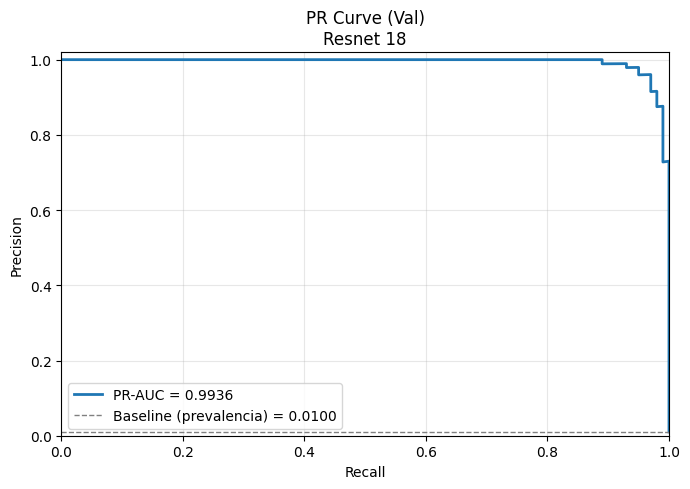

100%|██████████| 20/20 [00:08<00:00,  2.41it/s]


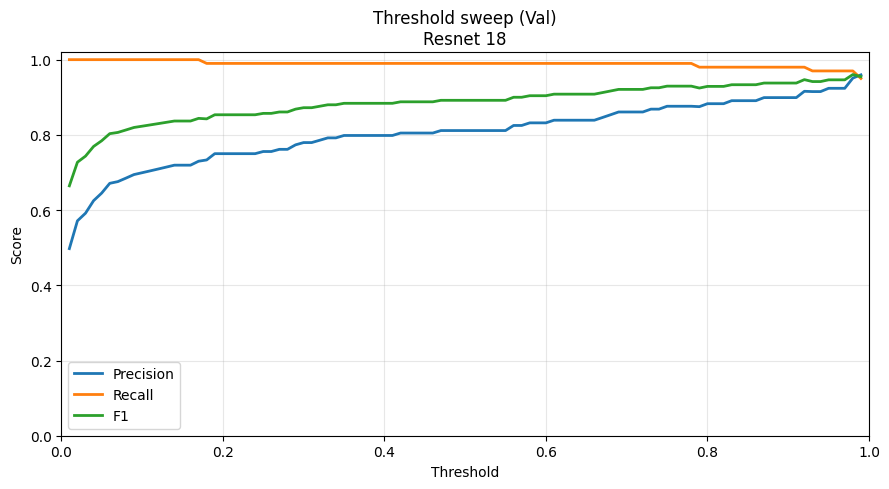

Mejor threshold según val: 0.980  (F1=0.960)


100%|██████████| 23/23 [00:09<00:00,  2.48it/s]


In [40]:
model = load_model('./05 Checkpoints/best_model_r18.pth')
pr_auc = plot_pr_curve(model, val_loader, DEVICE, title="PR Curve (Val)\nResnet 18", save_path='./06 Figures/pr_curve_r18.png')


best_thr, best_f1 = plot_threshold_sweep(model, val_loader, DEVICE, title="Threshold sweep (Val)\nResnet 18", save_path='./06 Figures/th_moving_r18.png')
print(f"Mejor threshold según val: {best_thr:.3f}  (F1={best_f1:.3f})")


labels_test, scores_test = get_scores_and_labels(model, test_loader, DEVICE)
metrics_test = compute_metrics(labels_test, scores_test, threshold=best_thr)
metrics_test_df = pd.DataFrame([metrics_test])

In [19]:
metrics_test_df

,accuracy,precision,recall,specificity,f1,pr_auc,roc_auc,tp,fp,tn,fn,threshold
0,0.999397,0.957983,0.982759,0.999565,0.970213,0.997848,0.999977,114,5,11479,2,0.98


100%|██████████| 20/20 [00:09<00:00,  2.21it/s]


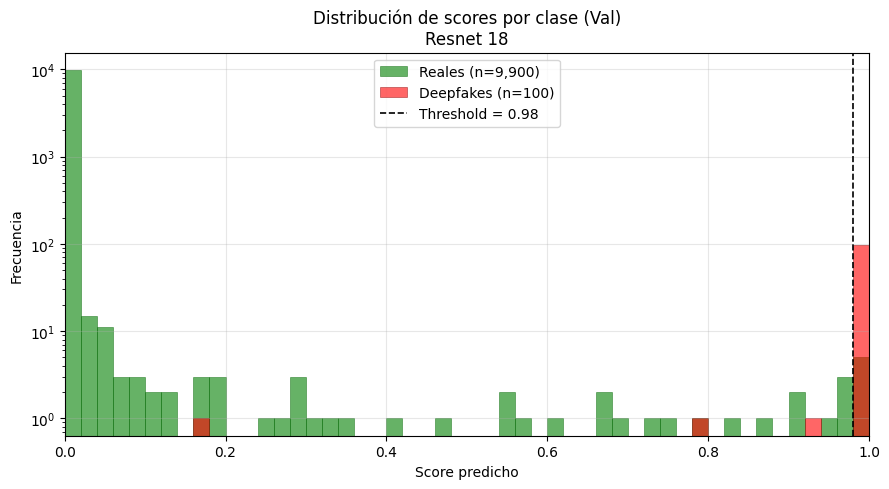

In [20]:
plot_score_histograms(model, val_loader, DEVICE,
                      threshold=0.98,
                      save_path='./06 Figures/score_histogram_val_r18.png',
                      title="Distribución de scores por clase (Val)\nResnet 18")

In [25]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [26]:
class BinaryClassifierOutputTarget:
    """Target para clasificadores binarios con un solo logit (shape [batch])."""
    def __call__(self, model_output):
        # model_output puede venir como [batch] o escalar tras squeeze
        if model_output.ndim == 0:
            return model_output
        return model_output[0]


def visualize_gradcam(model, image_path, device, threshold=0.98,
                      target_layer=None, save_path=None, title = 'Resnet 50'):
    """
    Genera Grad-CAM para una imagen y la visualiza con su score.
    """
    model.eval()

    if target_layer is None:
        target_layer = model.layer4[-1]

    img_rgb = np.array(Image.open(image_path).convert('RGB'))
    tensor = eval_transform(image=img_rgb)['image'].unsqueeze(0).to(device)

    with torch.no_grad():
        logit = model(tensor)
        score = torch.sigmoid(logit).item()

    is_fraud = score >= threshold
    label_text = "FRAUDE (Deepfake)" if is_fraud else "NO FRAUDE (Real)"
    color = 'red' if is_fraud else 'green'

    # Grad-CAM con target explícito para clasificador binario
    cam = GradCAM(model=model, target_layers=[target_layer])
    targets = [BinaryClassifierOutputTarget()]
    grayscale_cam = cam(input_tensor=tensor, targets=targets)[0]

    img_resized = cv2.resize(img_rgb, (224, 224))
    img_float = img_resized.astype(np.float32) / 255.0
    cam_overlay = show_cam_on_image(img_float, grayscale_cam, use_rgb=True)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(img_resized)
    axes[0].set_title("Original", fontsize=12)
    axes[0].axis('off')

    axes[1].imshow(cam_overlay)
    axes[1].set_title("Grad-CAM", fontsize=12)
    axes[1].axis('off')

    fig.suptitle(
        f"Score: {score:.4f}   |   Umbral: {threshold}   →   {label_text}\n{title}",
        fontsize=13, color=color, fontweight='bold',
    )

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()

    return score, is_fraud

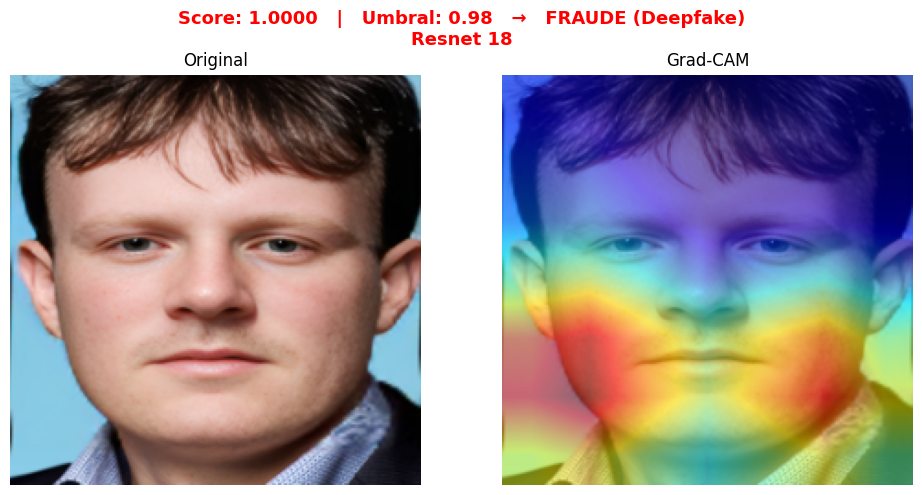

In [27]:
score, is_fraud = visualize_gradcam(
    model,
    image_path='./03 All Data/52401_62209.png',
    device=DEVICE,
    threshold=0.98,
    save_path='./06 Figures/gradcam_r18.png', title = 'Resnet 18'
)

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


def plot_confusion_matrix(labels, scores, threshold=0.5,
                          class_names=('Real', 'Deepfake'),
                          title="Matriz de Confusión",
                          save_path=None):
    """
    Matriz de confusión con verde suave para aciertos (TN, TP)
    y rojo suave para errores (FP, FN).
    """
    preds = (np.asarray(scores) >= threshold).astype(int)
    cm = confusion_matrix(labels, preds, labels=[0, 1])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    # Paleta minimalista
    good_color = '#d1fae5'   # verde menta suave (aciertos: TN, TP)
    bad_color  = '#fecaca'   # rojo coral suave (errores: FP, FN)
    text_color = '#1e293b'

    # Matriz de colores: diagonal = bueno, off-diagonal = malo
    color_matrix = np.array([
        [good_color, bad_color],   # fila 0: TN, FP
        [bad_color,  good_color],  # fila 1: FN, TP
    ])

    fig, ax = plt.subplots(figsize=(6, 5))

    # Pintar cada celda manualmente
    for i in range(2):
        for j in range(2):
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                       facecolor=color_matrix[i, j],
                                       edgecolor='white', linewidth=2))
            value = cm[i, j]
            pct = cm_norm[i, j] * 100
            ax.text(j, i, f"{value:,}\n({pct:.1f}%)",
                    ha='center', va='center', fontsize=13,
                    color=text_color, fontweight='medium')

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(1.5, -0.5)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(class_names, fontsize=11)
    ax.set_yticklabels(class_names, fontsize=11)
    ax.set_xlabel('Predicción', fontsize=12, color='#334155')
    ax.set_ylabel('Real', fontsize=12, color='#334155')
    ax.set_title(f"{title}  (thr = {threshold})", fontsize=13,
                 color='#1e293b', pad=15)

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(length=0, colors='#475569')
    ax.set_aspect('equal')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    return cm

100%|██████████| 20/20 [00:09<00:00,  2.03it/s]


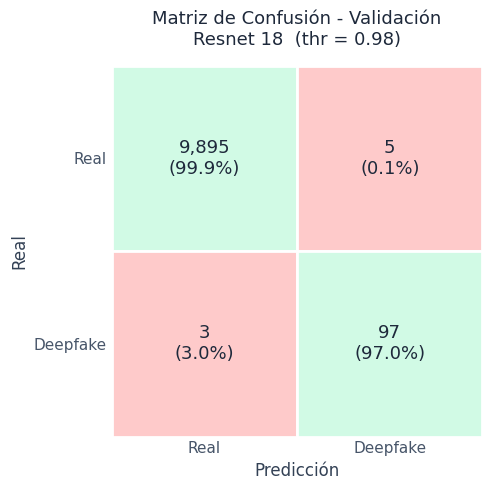

In [31]:
labels, scores = get_scores_and_labels(model, val_loader, DEVICE)

cm = plot_confusion_matrix(
    labels, scores,
    threshold=0.98,
    save_path='./06 Figures/confusion_matrix_val_r18.png',
    title="Matriz de Confusión - Validación\nResnet 18",
)

In [32]:
@torch.no_grad()
def get_scores_labels_and_paths(model, dataset, device, batch_size=32, num_workers=4):
    """
    Itera el dataset SIN shuffle para garantizar que paths/scores/labels estén alineados.
    """
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        num_workers=num_workers, pin_memory=True)

    model.eval()
    all_scores, all_labels = [], []
    for x, y in tqdm(loader, desc="Inferencia"):
        x = x.to(device, non_blocking=True)
        logits = model(x)
        scores = torch.sigmoid(logits).cpu().numpy()
        all_scores.extend(scores.tolist())
        all_labels.extend(y.numpy().tolist())

    # Paths en el mismo orden que el dataset
    paths = [f"{dataset.root_dir}/{p}" for p in dataset.paths]

    return np.array(all_labels), np.array(all_scores), paths


def plot_false_positives(model, dataset, device,
                         threshold=0.5, max_show=10, save_path=None):
    """Visualiza los False Positives: reales clasificados como deepfake."""
    labels, scores, paths = get_scores_labels_and_paths(model, dataset, device)

    fp_mask = (labels == 0) & (scores >= threshold)
    fp_indices = np.where(fp_mask)[0]

    if len(fp_indices) == 0:
        print("No hay falsos positivos a este threshold.")
        return

    fp_indices = fp_indices[np.argsort(-scores[fp_indices])]
    fp_indices = fp_indices[:max_show]
    n = len(fp_indices)

    fig, axes = plt.subplots(1, n, figsize=(n * 2.5, 3))
    if n == 1:
        axes = [axes]

    for ax, idx in zip(axes, fp_indices):
        img = Image.open(paths[idx]).convert('RGB')
        ax.imshow(img)
        ax.set_title(f"score={scores[idx]:.3f}", fontsize=10, color='#b91c1c')
        ax.axis('off')

    fig.suptitle(f"False Positives  (thr={threshold})\nResnet 18",
                 fontsize=12, color='#1e293b', y=1.02)

    plt.subplots_adjust(wspace=0.05)
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

Inferencia: 100%|██████████| 313/313 [00:14<00:00, 21.80it/s]


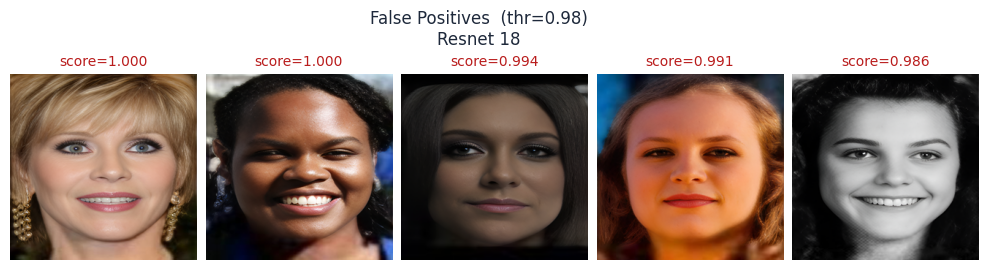

In [33]:
# Pasale el DATASET, no el loader
plot_false_positives(
    model, val_dataset,
    device=DEVICE,
    threshold=0.98,
    max_show=10,
    save_path='./06 Figures/false_positives_r18.png',
)

In [36]:
import time
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm


@torch.no_grad()
def measure_latency(model, dataset, device, batch_size=1, n_warmup=10, n_samples=200):
    """
    Mide latencia de inferencia por imagen.

    Args:
        batch_size: 1 para latencia por imagen (lo realista en KYC).
        n_warmup: forward passes iniciales descartados (GPU warmup).
        n_samples: cantidad de mediciones efectivas.

    Returns:
        latencies_ms: array de latencias en ms por imagen.
    """
    from torch.utils.data import DataLoader
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    it = iter(loader)

    model.eval()
    latencies_ms = []

    # Warmup (descartado)
    for _ in range(n_warmup):
        try:
            x, _ = next(it)
        except StopIteration:
            it = iter(loader); x, _ = next(it)
        x = x.to(device, non_blocking=True)
        _ = model(x)
        if device == 'cuda':
            torch.cuda.synchronize()

    # Medición
    for _ in tqdm(range(n_samples), desc="Midiendo latencia"):
        try:
            x, _ = next(it)
        except StopIteration:
            it = iter(loader); x, _ = next(it)
        x = x.to(device, non_blocking=True)

        if device == 'cuda':
            torch.cuda.synchronize()
        t0 = time.perf_counter()

        _ = model(x)

        if device == 'cuda':
            torch.cuda.synchronize()
        t1 = time.perf_counter()

        latencies_ms.append((t1 - t0) * 1000 / batch_size)

    latencies_ms = np.array(latencies_ms)

    # Reporte
    print(f"\n--- Latencia de inferencia ({device}, batch_size={batch_size}) ---")
    print(f"  Mean:   {latencies_ms.mean():.2f} ms")
    print(f"  Median: {np.median(latencies_ms):.2f} ms")
    print(f"  Std:    {latencies_ms.std():.2f} ms")
    print(f"  P95:    {np.percentile(latencies_ms, 95):.2f} ms")
    print(f"  P99:    {np.percentile(latencies_ms, 99):.2f} ms")
    print(f"  Min:    {latencies_ms.min():.2f} ms")
    print(f"  Max:    {latencies_ms.max():.2f} ms")
    print(f"  Throughput: {1000 / latencies_ms.mean():.1f} imágenes/seg")

    return latencies_ms


def plot_latency_distribution(latencies_ms, save_path=None, title = 'Resnet 50'):
    """Box plot + histograma de latencias."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Histograma
    ax1.hist(latencies_ms, bins=40, color='#60a5fa', edgecolor='#1e40af',
             alpha=0.7, linewidth=0.5)
    ax1.axvline(latencies_ms.mean(), ls='--', color='red', lw=1.5,
                label=f'Mean = {latencies_ms.mean():.2f} ms')
    ax1.axvline(np.percentile(latencies_ms, 95), ls='--', color='orange', lw=1.5,
                label=f'P95 = {np.percentile(latencies_ms, 95):.2f} ms')
    ax1.set_xlabel('Latencia (ms)')
    ax1.set_ylabel('Frecuencia')
    ax1.set_title(f'Distribución de latencia por imagen\n{title}')
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Box plot
    ax2.boxplot(latencies_ms, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#60a5fa', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
    ax2.set_ylabel('Latencia (ms)')
    ax2.set_title(f'Box plot de latencia\n{title}')
    ax2.set_xticklabels(['Inferencia'])
    ax2.grid(alpha=0.3, axis='y')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()

Midiendo latencia: 100%|██████████| 200/200 [00:01<00:00, 191.29it/s]



--- Latencia de inferencia (cuda, batch_size=1) ---
  Mean:   2.87 ms
  Median: 2.76 ms
  Std:    0.22 ms
  P95:    3.15 ms
  P99:    3.72 ms
  Min:    2.65 ms
  Max:    3.97 ms
  Throughput: 348.1 imágenes/seg


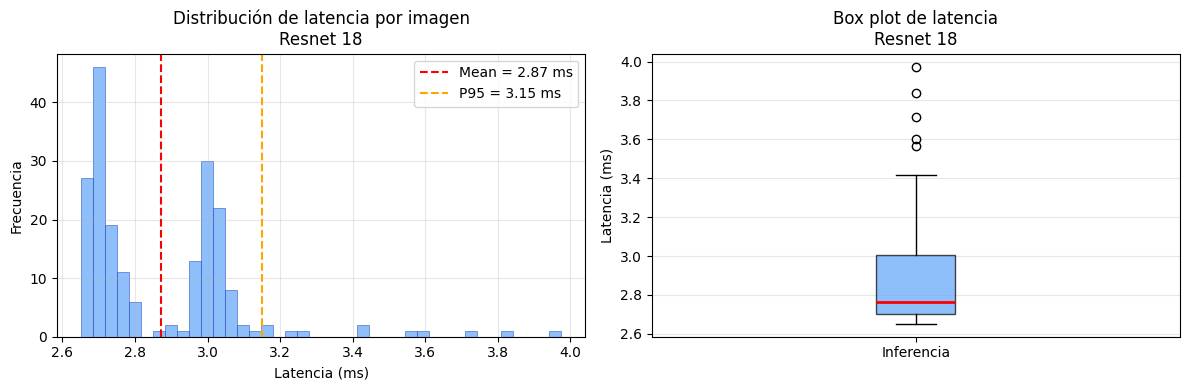

In [37]:
latencies = measure_latency(model, val_dataset, DEVICE,
                            batch_size=1, n_warmup=10, n_samples=200)

plot_latency_distribution(latencies, save_path='./06 Figures/latency_r18.png', title = 'Resnet 18')

### Test

100%|██████████| 23/23 [00:12<00:00,  1.80it/s]


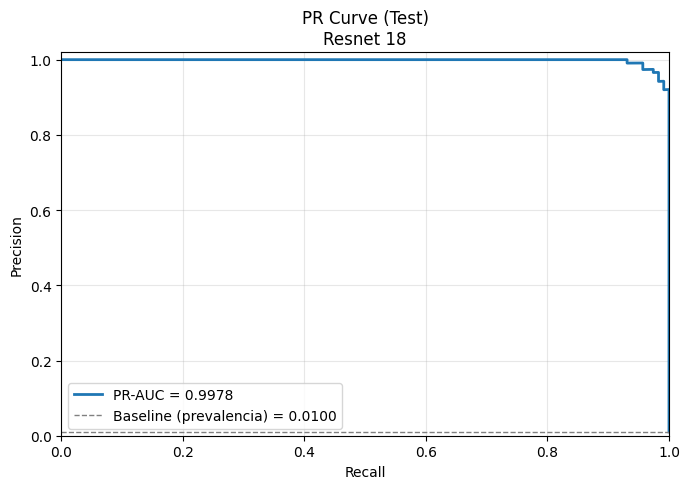

100%|██████████| 20/20 [00:11<00:00,  1.75it/s]


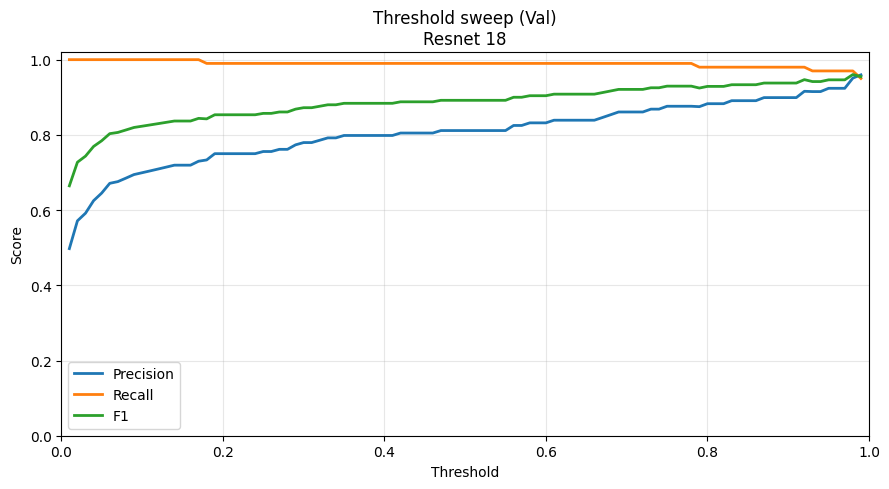

Mejor threshold según val: 0.980  (F1=0.960)


100%|██████████| 23/23 [00:13<00:00,  1.66it/s]


,accuracy,precision,recall,specificity,f1,pr_auc,roc_auc,tp,fp,tn,fn,threshold
0,0.999397,0.957983,0.982759,0.999565,0.970213,0.997848,0.999977,114,5,11479,2,0.98


In [38]:
model = load_model('./05 Checkpoints/best_model_r18.pth')
pr_auc = plot_pr_curve(model, test_loader, DEVICE, title="PR Curve (Test)\nResnet 18", save_path='./06 Figures/test/pr_curve_r18_test.png')


best_thr, best_f1 = plot_threshold_sweep(model, val_loader, DEVICE, title="Threshold sweep (Val)\nResnet 18", save_path='./06 Figures/test/th_moving_r18_test.png')
print(f"Mejor threshold según val: {best_thr:.3f}  (F1={best_f1:.3f})")


labels_test, scores_test = get_scores_and_labels(model, test_loader, DEVICE)
metrics_test = compute_metrics(labels_test, scores_test, threshold=best_thr)
metrics_test_df = pd.DataFrame([metrics_test])
metrics_test_df

In [39]:
metrics_test_df['modelo'] = 'resnet18'
print(metrics_test_df.to_markdown(index = False))

|   accuracy |   precision |   recall |   specificity |       f1 |   pr_auc |   roc_auc |   tp |   fp |    tn |   fn |   threshold | modelo   |
|-----------:|------------:|---------:|--------------:|---------:|---------:|----------:|-----:|-----:|------:|-----:|------------:|:---------|
|   0.999397 |    0.957983 | 0.982759 |      0.999565 | 0.970213 | 0.997848 |  0.999977 |  114 |    5 | 11479 |    2 |        0.98 | resnet18 |


In [42]:
metrics_test_df['modelo'] = 'resnet18'
print(metrics_test_df.to_markdown(index = False))

|   accuracy |   precision |   recall |   specificity |       f1 |   pr_auc |   roc_auc |   tp |   fp |    tn |   fn |   threshold | modelo   |
|-----------:|------------:|---------:|--------------:|---------:|---------:|----------:|-----:|-----:|------:|-----:|------------:|:---------|
|   0.999397 |    0.957983 | 0.982759 |      0.999565 | 0.970213 | 0.997848 |  0.999977 |  114 |    5 | 11479 |    2 |        0.98 | resnet18 |


100%|██████████| 23/23 [00:09<00:00,  2.44it/s]


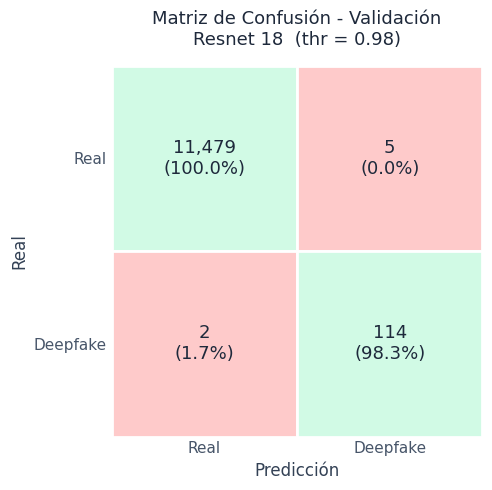

In [43]:
labels, scores = get_scores_and_labels(model, test_loader, DEVICE)

cm = plot_confusion_matrix(
    labels, scores,
    threshold=0.98,
    save_path='./06 Figures/test/confusion_matrix_val_r18.png',
    title="Matriz de Confusión - Validación\nResnet 18",
)